In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Mobiles Dataset (2025).csv to Mobiles Dataset (2025).csv


In [3]:
df = pd.read_csv("Mobiles Dataset (2025).csv")

print(df.head())
print(df.columns)

  Company Name            Model Name Mobile Weight  RAM Front Camera  \
0        Apple       iPhone 16 128GB          174g  6GB         12MP   
1        Apple       iPhone 16 256GB          174g  6GB         12MP   
2        Apple       iPhone 16 512GB          174g  6GB         12MP   
3        Apple  iPhone 16 Plus 128GB          203g  6GB         12MP   
4        Apple  iPhone 16 Plus 256GB          203g  6GB         12MP   

  Back Camera   Processor Battery Capacity Screen Size Launched Price (India)  \
0        48MP  A17 Bionic         3,600mAh  6.1 inches             INR 79,999   
1        48MP  A17 Bionic         3,600mAh  6.1 inches             INR 84,999   
2        48MP  A17 Bionic         3,600mAh  6.1 inches             INR 89,999   
3        48MP  A17 Bionic         4,200mAh  6.7 inches             INR 89,999   
4        48MP  A17 Bionic         4,200mAh  6.7 inches             INR 94,999   

   Launched Year  
0           2024  
1           2024  
2           2024  
3   

In [4]:
df.columns = df.columns.str.strip()

print(df.shape)
print(df.isnull().sum())

(930, 11)
Company Name              0
Model Name                0
Mobile Weight             0
RAM                       0
Front Camera              0
Back Camera               0
Processor                 0
Battery Capacity          0
Screen Size               0
Launched Price (India)    0
Launched Year             0
dtype: int64


In [5]:
current_year = 2026

# Device Age
df['Device_Age'] = current_year - df['Launched Year']

# Charge Cycles
df['Charge_Cycles'] = df['Device_Age'].apply(
    lambda x: random.randint(
        max(50, int(x*200)),
        max(100, int(x*400))
    )
)

# Battery Health
df['Battery_Health'] = (
    100 - (df['Charge_Cycles'] * 0.025)
).clip(lower=70, upper=100)

# Temperature
df['Temperature'] = (
    28 +
    (df['Device_Age'] * 1.5) +
    np.random.uniform(0,5,len(df))
)

# Voltage
df['Voltage'] = np.random.uniform(
    3.7,
    4.2,
    len(df)
)

In [6]:
def health_status(x):

    if x >= 90:
        return "Good"

    elif x >= 80:
        return "Moderate"

    else:
        return "Poor"

df['Health_Status'] = df['Battery_Health'].apply(
    health_status
)

df.head()

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (India),Launched Year,Device_Age,Charge_Cycles,Battery_Health,Temperature,Voltage,Health_Status
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"INR 79,999",2024,2,508,87.300,34.433584,4.192626,Moderate
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"INR 84,999",2024,2,586,85.350,33.416195,4.163959,Moderate
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"INR 89,999",2024,2,755,81.125,31.075369,4.120295,Moderate
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"INR 89,999",2024,2,402,89.950,31.809706,4.015160,Moderate
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"INR 94,999",2024,2,641,83.975,32.208149,4.009774,Moderate


In [7]:
print(df[
[
'Device_Age',
'Charge_Cycles',
'Battery_Health',
'Temperature',
'Voltage',
'Health_Status'
]
].head())

   Device_Age  Charge_Cycles  Battery_Health  Temperature   Voltage  \
0           2            508          87.300    34.433584  4.192626   
1           2            586          85.350    33.416195  4.163959   
2           2            755          81.125    31.075369  4.120295   
3           2            402          89.950    31.809706  4.015160   
4           2            641          83.975    32.208149  4.009774   

  Health_Status  
0      Moderate  
1      Moderate  
2      Moderate  
3      Moderate  
4      Moderate  


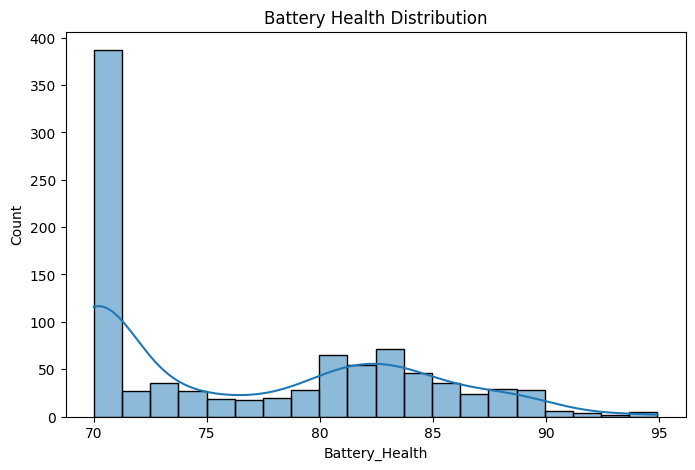

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Battery_Health'],
    bins=20,
    kde=True
)

plt.title("Battery Health Distribution")

plt.show()

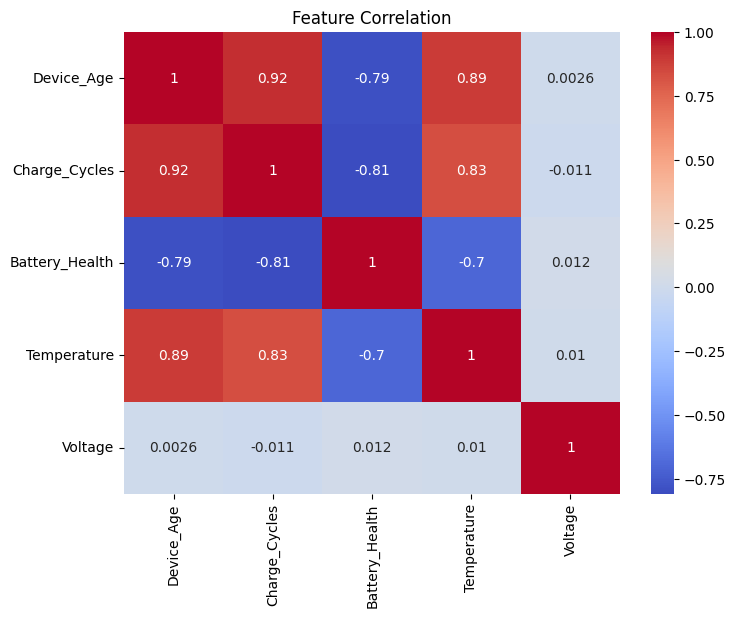

In [9]:
corr_df = df[
[
'Device_Age',
'Charge_Cycles',
'Battery_Health',
'Temperature',
'Voltage'
]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation")

plt.show()

In [10]:
X = df[
[
'Device_Age',
'Charge_Cycles',
'Temperature',
'Voltage'
]
]

y = df['Health_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [11]:
y_pred = model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 1.0
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00         4
    Moderate       1.00      1.00      1.00        79
        Poor       1.00      1.00      1.00       103

    accuracy                           1.00       186
   macro avg       1.00      1.00      1.00       186
weighted avg       1.00      1.00      1.00       186



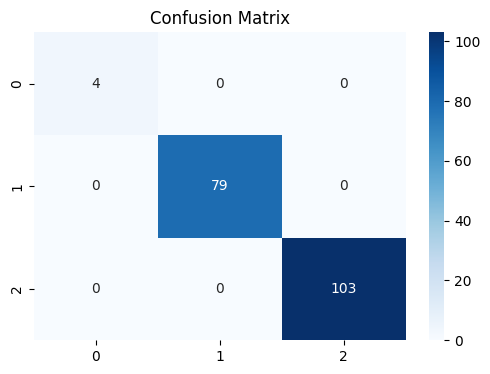

In [12]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.show()

In [13]:
sample = pd.DataFrame({

'Device_Age':[2],

'Charge_Cycles':[500],

'Temperature':[35],

'Voltage':[4.0]

})

prediction = model.predict(sample)

print(
    "Predicted Health:",
    prediction[0]
)

Predicted Health: Moderate


In [14]:
print(df.columns)

Index(['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera',
       'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size',
       'Launched Price (India)', 'Launched Year', 'Device_Age',
       'Charge_Cycles', 'Battery_Health', 'Temperature', 'Voltage',
       'Health_Status'],
      dtype='object')
